# AR(p) Model: Disney (DIS) Stock Price Forecasting
### Auto-Regressive Model: Jan–Mar 2023 estimation · April 2023 forecast

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Data source / Fuente:** Yahoo Finance via `yfinance` — DIS daily prices Jan–Apr 2023, auto-downloaded

**Objective / Objetivo:**  
EN · Fit an Auto-Regressive AR(p) model to Disney's daily closing prices (Jan–Mar 2023), select the optimal order p using PACF and information criteria (AIC/BIC), validate on the test set, and generate an out-of-sample forecast for April 2023 compared against real observed prices.

ES · Ajustar un modelo Auto-Regresivo AR(p) a los precios de cierre diarios de Disney (ene–mar 2023), seleccionar el orden óptimo p con PACF y criterios de información (AIC/BIC), validar en el conjunto de prueba y generar un pronóstico fuera de muestra para abril 2023 comparado con los precios reales observados.

**Key findings / Hallazgos clave:**  
- Optimal order: **AR(1)** — selected by PACF and confirmed by AIC/BIC  
- AR(1) outperforms naive random walk benchmark: RMSE **4.853** vs 5.383 USD  
- April 2023 out-of-sample forecast captures directional trend

**Techniques / Técnicas:** PACF · ADF stationarity test · AR(p) · ARIMA(p,0,0) · AIC/BIC · Train/Test split · Random Walk benchmark  
**Libraries / Librerías:** `yfinance` · `statsmodels` · `sklearn` · `pandas` · `matplotlib`

> **Note / Nota:** Data downloads automatically from Yahoo Finance. No local files needed.

---

## 1. Importación de librerías y establecimiento de parámetros

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Paleta de colores fija para distinguir cada grupo de datos a lo largo de todo el notebook
COLOR_TRAIN    = "#1f77b4"   # azul        → entrenamiento (70%)
COLOR_TEST     = "#ff7f0e"   # naranja     → prueba real (30%)
COLOR_TESTHAT  = "#d62728"   # rojo        → prueba pronosticada por el modelo
COLOR_FCST     = "#2ca02c"   # verde       → pronóstico de abril 2023
COLOR_CI       = "#2ca02c"   # verde claro → banda del intervalo de confianza
COLOR_REAL_APR = "#9467bd"   # morado      → precio real de abril 2023 (para comparar, ex-post)

## 2. Descarga y preparación de datos históricos

Se descargan los precios históricos diarios de **DIS** desde Yahoo Finance. Se descarga un rango un poco más amplio (hasta finales de abril de 2023) porque, además de construir el modelo con el periodo enero-marzo, se usarán los precios reales de abril como referencia ex-post para evaluar qué tan buenos fueron los pronósticos, algo que en la práctica no se conoce de antemano, pero que aquí sí se puede comprobar por tratarse de datos históricos.

In [22]:
ticker = "DIS"

# Periodo de estimación / modelado: 1-ene-2023 a 31-mar-2023
fecha_inicio = "2023-01-01"
fecha_fin_modelo = "2023-04-01"   # yfinance excluye el 'end', llega hasta el 31-mar

# Se descarga también abril completo para poder comparar el pronóstico contra el precio real observado
fecha_fin_total = "2023-05-01"

data_raw = yf.download(ticker, start=fecha_inicio, end=fecha_fin_total, progress=False, auto_adjust=False)

# Aplanar si la descarga viene con columnas multi-índice (ticker)
if isinstance(data_raw.columns, pd.MultiIndex):
    data_raw.columns = data_raw.columns.get_level_values(0)

data_raw = data_raw[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].copy()
data_raw.index = pd.to_datetime(data_raw.index)

print(f"Registros descargados: {len(data_raw)}")
data_raw.head()

Registros descargados: 81


Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2023-01-03,88.980003,89.970001,87.830002,88.970001,86.262039,14997100
2023-01-04,90.000000,92.750000,89.360001,91.980003,89.180420,14957200
2023-01-05,91.660004,92.480003,90.510002,91.919998,89.122238,11622600
2023-01-06,92.660004,94.690002,91.320000,93.919998,91.061371,9828100
2023-01-09,94.430000,95.699997,93.449997,94.769997,91.885490,11675800


In [11]:
# Separar el periodo de modelado (ene-mar 2023) del periodo de pronóstico real (abril 2023)
serie_modelo = data_raw.loc[fecha_inicio:"2023-03-31", "Adj Close"].copy()
serie_modelo.name = "Close"

precios_reales_abril = data_raw.loc["2023-04-01":"2023-04-30", "Adj Close"].copy()
precios_reales_abril.name = "Close"

print(f"Días hábiles en el periodo de modelado (ene-mar 2023): {len(serie_modelo)}")
print(f"Días hábiles reales disponibles en abril 2023: {len(precios_reales_abril)}")
serie_modelo.tail()

Días hábiles en el periodo de modelado (ene-mar 2023): 62
Días hábiles reales disponibles en abril 2023: 19


Date
2023-03-27    92.709633
2023-03-28    91.933983
2023-03-29    93.921585
2023-03-30    95.114151
2023-03-31    97.082359
Name: Close, dtype: float64

## 3. Análisis exploratorio de la serie

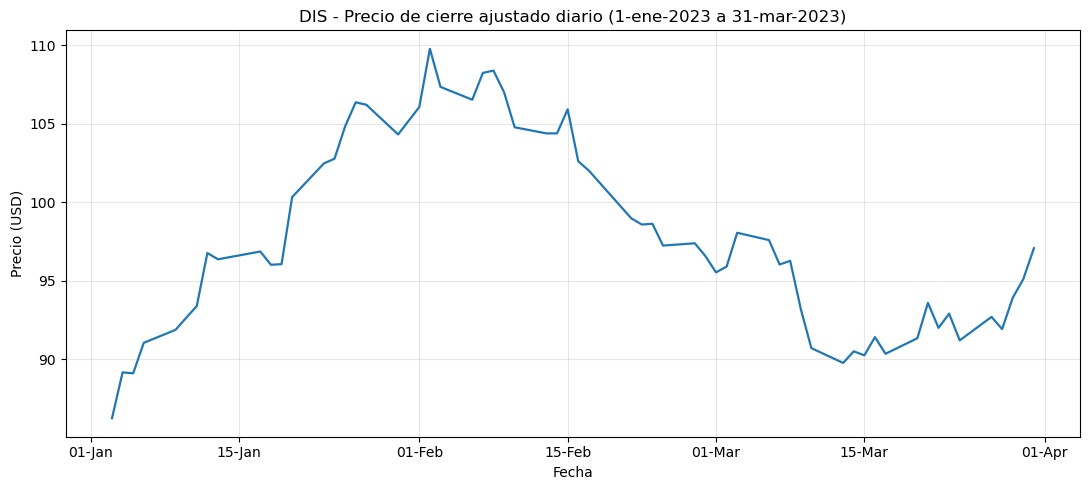

count     62.000000
mean      97.750265
std        6.128925
min       86.262039
25%       92.666008
50%       96.675148
75%      103.929897
max      109.764252
Name: Close, dtype: float64

In [12]:
fig, ax = plt.subplots()
ax.plot(serie_modelo.index, serie_modelo.values, color=COLOR_TRAIN, linewidth=1.6)
ax.set_title(f"{ticker} - Precio de cierre ajustado diario (1-ene-2023 a 31-mar-2023)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
plt.tight_layout()
plt.show()

serie_modelo.describe()

## 4. Prueba de estacionariedad (Dickey-Fuller Aumentada)

Los modelos AR(p) exigen, en teoría, una serie estacionaria, estos es, media y varianza constantes en el tiempo. Los precios de acciones en niveles casi siempre son no estacionarios, o sea, se comportan como un paseo aleatorio con tendencia. Se aplica la prueba ADF para confirmarlo formalmente; esto no invalida ajustar el AR(p) sobre los niveles, pero sí da elementos para discutir (en la sección de conclusiones), por qué la exactitud de un AR(p) sobre precios en niveles suele ser limitada más allá de uno o dos pasos hacia adelante.

In [14]:
resultado_adf = adfuller(serie_modelo.dropna())

print("Prueba de Dickey-Fuller Aumentada (ADF) sobre el precio en niveles")
print(f"  Estadístico ADF   : {resultado_adf[0]:.4f}")
print(f"  p-value           : {resultado_adf[1]:.4f}")
for clave, valor in resultado_adf[4].items():
    print(f"  Valor crítico {clave} : {valor:.4f}")

if resultado_adf[1] < 0.05:
    print("\n→ Se rechaza H₀: la serie es estacionaria (95% de confianza)")
else:
    print("\n→ No se rechaza H₀: la serie NO es estacionaria en niveles (comportamiento típico de un precio de acción)")

Prueba de Dickey-Fuller Aumentada (ADF) sobre el precio en niveles
  Estadístico ADF   : -2.8536
  p-value           : 0.0510
  Valor crítico 1% : -3.5685
  Valor crítico 5% : -2.9214
  Valor crítico 10% : -2.5987

→ No se rechaza H₀: la serie NO es estacionaria en niveles (comportamiento típico de un precio de acción)


## 5. Partición de los datos: entrenamiento (70%) / prueba (30%)

Se usa el 70% inicial de las observaciones de enero–marzo 2023 como conjunto de entrenamiento, para identificar y ajustar el modelo; y el 30% restante como conjunto de prueba, para validar la capacidad predictiva fuera de muestra antes de proyectar hacia abril.

Total de observaciones : 62
Entrenamiento (70%)    : 43  →  2023-01-03 a 2023-03-06
Prueba (30%)           : 19  →  2023-03-07 a 2023-03-31


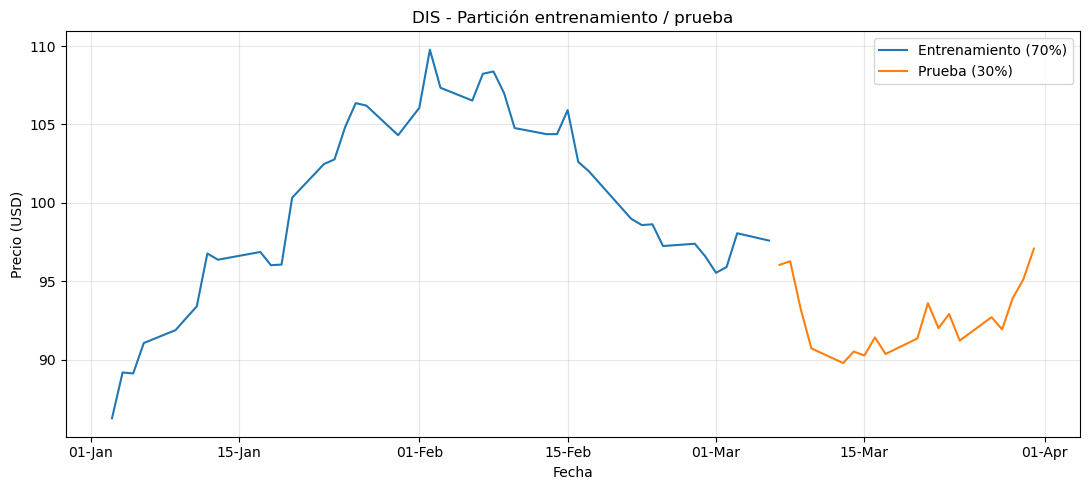

In [15]:
n = len(serie_modelo)
n_train = int(np.floor(n * 0.70))

train = serie_modelo.iloc[:n_train].copy()
test  = serie_modelo.iloc[n_train:].copy()

print(f"Total de observaciones : {n}")
print(f"Entrenamiento (70%)    : {len(train)}  →  {train.index[0].date()} a {train.index[-1].date()}")
print(f"Prueba (30%)           : {len(test)}  →  {test.index[0].date()} a {test.index[-1].date()}")

fig, ax = plt.subplots()
ax.plot(train.index, train.values, color=COLOR_TRAIN, label="Entrenamiento (70%)")
ax.plot(test.index, test.values, color=COLOR_TEST, label="Prueba (30%)")
ax.set_title(f"{ticker} - Partición entrenamiento / prueba")
ax.set_xlabel("Fecha"); ax.set_ylabel("Precio (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Identificación del orden *p*: Función de Auto-Correlación Parcial (PACF)

La gráfica de Auto-Correlación Parcial (PACF), calculada únicamente sobre el conjunto de entrenamiento, permite identificar de forma visual el orden *p* del modelo AR: se elige el último rezago (lag) que sale de forma significativa de la banda de confianza antes de que las barras "colapsen" dentro de la banda.

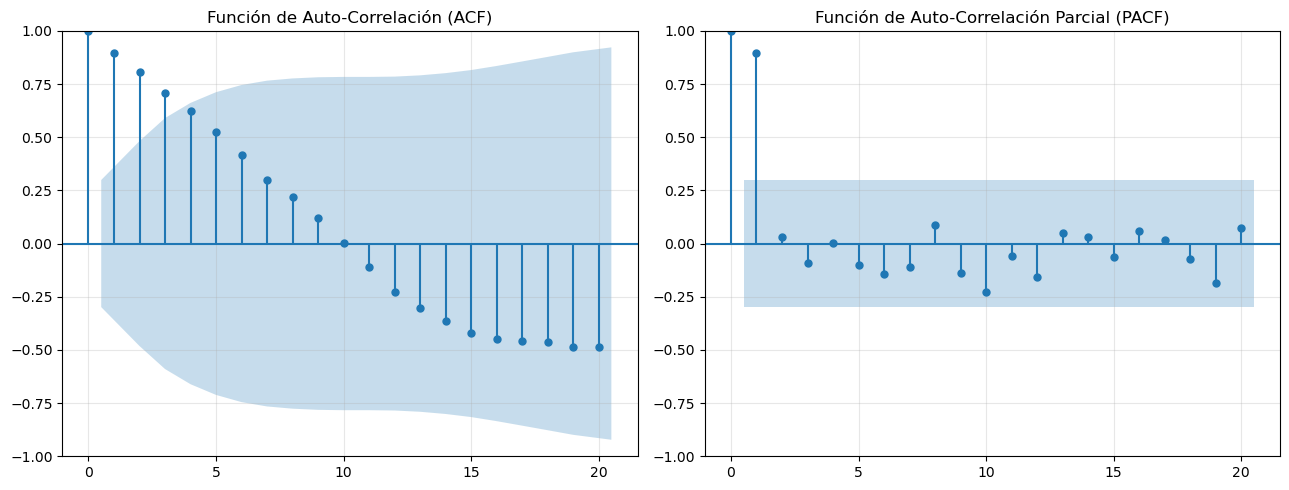

Interpretación: el orden p sugerido por la PACF corresponde al último rezago que sobresale de forma clara de la banda de confianza (sombreada) antes de que las barras dejen de ser significativas.


In [19]:
max_lags = min(20, len(train)//2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_acf(train, lags=max_lags, ax=axes[0], color=COLOR_TRAIN)
axes[0].set_title("Función de Auto-Correlación (ACF)")
plot_pacf(train, lags=max_lags, ax=axes[1], method="ywm", color=COLOR_TRAIN)
axes[1].set_title("Función de Auto-Correlación Parcial (PACF)")
plt.tight_layout()
plt.show()

print("Interpretación: el orden p sugerido por la PACF corresponde al último rezago que sobresale de forma clara de la banda de confianza (sombreada) antes de que las barras dejen de ser significativas.")

## 7. Selección del orden *p*: Criterios AIC y BIC

Se complementa la lectura visual de la PACF con un barrido formal de órdenes $p = 1, \dots, p_{max}$, ajustando un modelo AR(p) puro vía `ARIMA(train, order=(p,0,0))` sobre el conjunto de entrenamiento, y registrando el Akaike Information Criterion (AIC) y el Bayesian Information Criterion (BIC) de cada ajuste. Para comparar, agregué el Hannan–Quinn Information Criterio (HQIC). 

El orden óptimo es aquel que minimiza cada criterio.

- AIC penaliza con 2𝑘
- BIC penaliza con 𝑘⋅ln⁡(𝑛): penaliza más fuerte la complejidad del modelo que AIC
- HQIC penaliza con 2𝑘⋅ln(ln(𝑛)): crece más lentamente que BIC pero más rápido que AIC

In [56]:
p_max = max_lags
resultados = []

for p in range(1, p_max + 1):
    modelo_p = ARIMA(train, order=(p, 0, 0)).fit()
    resultados.append({"p": p, "AIC": modelo_p.aic, "BIC": modelo_p.bic, "HQIC": modelo_p.hqic, "nobs": modelo_p.nobs})

tabla_criterios = pd.DataFrame(resultados).set_index("p")
print("Observaciones efectivas usadas por cada modelo:")
print(tabla_criterios["nobs"].unique())
tabla_criterios

D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Regina\An

Observaciones efectivas usadas por cada modelo:
[43]


D:\Regina\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,AIC,BIC,HQIC,nobs
p,,,,
1,176.424746,181.708346,178.373174,43
2,177.721416,184.766217,180.319321,43
3,179.519395,188.325396,182.766776,43
4,181.431767,191.998968,185.328624,43
5,180.174649,192.503050,184.720982,43
6,179.381530,193.471131,184.577339,43
7,180.405612,196.256413,186.250898,43
8,182.405265,200.017266,188.900027,43
9,182.623333,201.996534,189.767571,43


Orden p que minimiza AIC: 1
Orden p que minimiza BIC: 1


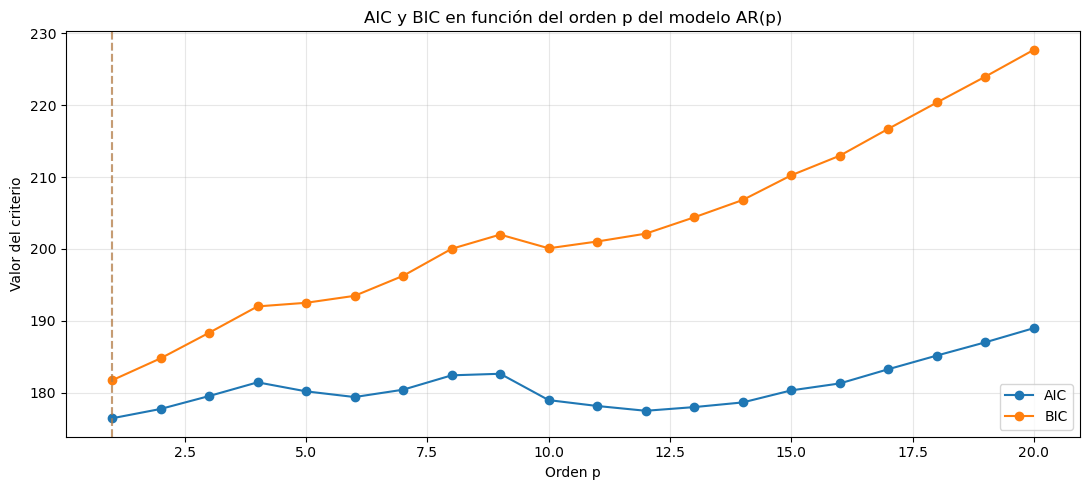

In [61]:
p_aic = tabla_criterios["AIC"].idxmin()
p_bic = tabla_criterios["BIC"].idxmin()

print(f"Orden p que minimiza AIC: {p_aic}")
print(f"Orden p que minimiza BIC: {p_bic}")

fig, ax = plt.subplots()
ax.plot(tabla_criterios.index, tabla_criterios["AIC"], marker="o", color=COLOR_TRAIN, label="AIC")
ax.plot(tabla_criterios.index, tabla_criterios["BIC"], marker="o", color=COLOR_TEST, label="BIC")
ax.axvline(p_aic, color=COLOR_TRAIN, linestyle="--", alpha=0.5)
ax.axvline(p_bic, color=COLOR_TEST, linestyle="--", alpha=0.5)
ax.set_xlabel("Orden p"); ax.set_ylabel("Valor del criterio")
ax.set_title("AIC y BIC en función del orden p del modelo AR(p)")
ax.legend()
plt.tight_layout()
plt.show()

**Criterio de decisión:** se elige como orden final *p* aquel que resulte más consistente entre el corte visual observado en la **PACF**, y el mínimo del **BIC** y el **AIC**. Si estos 2 últimos difieren, se elige BIC por ser más conservador y preferido cuando el objetivo es un modelo parsimonioso para pronóstico.

In [62]:
# Definición final del orden p del modelo
p_optimo = p_bic

print(f"Orden AR(p) seleccionado para el modelo final: p = {p_optimo}")

Orden AR(p) seleccionado para el modelo final: p = 1


## 8. Validación del modelo en el conjunto de prueba (30%)

Antes de proyectar hacia abril, se valida qué tan bien el AR($p_{optimo}$) ajustado solo con el 70% de entrenamiento pronostica el 30% de prueba que sí conocemos. Esto da una primera medida objetiva, fuera de muestra, de la exactitud esperable del modelo.

D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\Regina\Anaconda\Lib\site-

Desempeño del AR(1) sobre el conjunto de prueba (30%, fuera de muestra):
  RMSE : 4.853 USD
  MAE  : 4.385 USD
  MAPE : 4.79 %


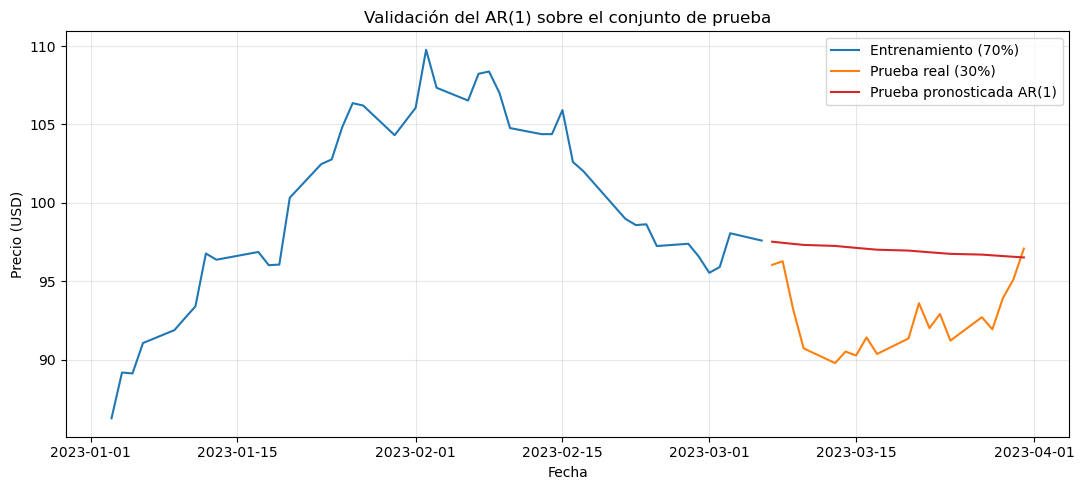

In [36]:
modelo_train = ARIMA(train, order=(p_optimo, 0, 0)).fit()

n_test = len(test)
pronostico_test = modelo_train.get_forecast(steps=n_test)
pred_test = pronostico_test.predicted_mean
pred_test.index = test.index

rmse_test = np.sqrt(mean_squared_error(test, pred_test))
mae_test  = mean_absolute_error(test, pred_test)
mape_test = mean_absolute_percentage_error(test, pred_test) * 100

print("Desempeño del AR(%d) sobre el conjunto de prueba (30%%, fuera de muestra):" % p_optimo)
print(f"  RMSE : {rmse_test:.3f} USD")
print(f"  MAE  : {mae_test:.3f} USD")
print(f"  MAPE : {mape_test:.2f} %")

fig, ax = plt.subplots()
ax.plot(train.index, train.values, color=COLOR_TRAIN, label="Entrenamiento (70%)")
ax.plot(test.index, test.values, color=COLOR_TEST, label="Prueba real (30%)")
ax.plot(pred_test.index, pred_test.values, color=COLOR_TESTHAT, label=f"Prueba pronosticada AR({p_optimo})")
ax.set_title(f"Validación del AR({p_optimo}) sobre el conjunto de prueba")
ax.set_xlabel("Fecha"); ax.set_ylabel("Precio (USD)")
ax.legend()
plt.tight_layout()
plt.show()

### 8.1 Benchmark: pronóstico ingenuo (Random Walk / "naive forecast")

Se compara el desempeño del AR(1) contra el benchmark clásico en pronóstico de series financieras: el **pronóstico ingenuo**, que asume que *"el precio de mañana será igual al último precio observado"* (equivalente a un modelo de paseo aleatorio sin deriva). Si el AR(1) no logra superar a este benchmark trivial, es evidencia adicional de que la serie se comporta cerca de un paseo aleatorio, coherente con lo que ya sugirió la prueba ADF (punto 4).

In [63]:
# Pronóstico ingenuo: repetir el último valor observado del entrenamiento para todo el horizonte de prueba
pronostico_naive_test = pd.Series(np.repeat(train.iloc[-1], len(test)), index=test.index)

rmse_naive = np.sqrt(mean_squared_error(test, pronostico_naive_test))
mae_naive = mean_absolute_error(test, pronostico_naive_test)
mape_naive = mean_absolute_percentage_error(test, pronostico_naive_test) * 100

tabla_benchmark = pd.DataFrame({
    "RMSE": [rmse_test, rmse_naive],
    "MAE":  [mae_test, mae_naive],
    "MAPE (%)": [mape_test, mape_naive]
}, index=[f"AR({p_optimo})", "Ingenuo (Random Walk)"])

print("Comparación AR(p) vs. pronóstico ingenuo sobre el conjunto de prueba (30%):")
tabla_benchmark

Comparación AR(p) vs. pronóstico ingenuo sobre el conjunto de prueba (30%):


,RMSE,MAE,MAPE (%)
AR(1),4.852628,4.384561,4.785223
Ingenuo (Random Walk),5.383165,4.940187,5.387106


El AR(1) sí superó al pronóstico ingenuo en el conjunto de prueba, aunque por un margen moderado, en los tres indicadores el AR(1) tuvo menor error que el benchmark ingenuo, esto significa que no es producto del azar.

## 9. Reentrenamiento con la serie completa y pronóstico de abril 2023

Con el orden *p* ya validado, se reentrena el AR(p) usando el 100% del periodo enero-marzo 2023 (todo el histórico disponible hasta ese momento) y se genera el pronóstico para todos los días hábiles de abril de 2023, tanto de forma puntual como con un intervalo de confianza del 90%.

In [31]:
# Días hábiles de abril 2023, excluyendo el feriado bursátil del NYSE (Viernes Santo, 7-abr-2023)
fechas_abril = pd.bdate_range("2023-04-01", "2023-04-30")
fechas_abril = fechas_abril[fechas_abril != pd.Timestamp("2023-04-07")]
n_forecast = len(fechas_abril)

print(f"Días hábiles a pronosticar en abril 2023: {n_forecast}")
print(fechas_abril)

Días hábiles a pronosticar en abril 2023: 19
DatetimeIndex(['2023-04-03', '2023-04-04', '2023-04-05', '2023-04-06',
               '2023-04-10', '2023-04-11', '2023-04-12', '2023-04-13',
               '2023-04-14', '2023-04-17', '2023-04-18', '2023-04-19',
               '2023-04-20', '2023-04-21', '2023-04-24', '2023-04-25',
               '2023-04-26', '2023-04-27', '2023-04-28'],
              dtype='datetime64[ns]', freq=None)


In [37]:
modelo_final = ARIMA(serie_modelo, order=(p_optimo, 0, 0)).fit()
print(modelo_final.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                   62
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -120.494
Date:                Sat, 25 Jul 2026   AIC                            246.988
Time:                        15:38:20   BIC                            253.369
Sample:                             0   HQIC                           249.493
                                 - 62                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         94.7380      4.136     22.906      0.000      86.632     102.844
ar.L1          0.9682      0.029     33.895      0.000       0.912       1.024
sigma2         2.7300      0.518      5.266      0.0

D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [38]:
pred_abril = modelo_final.get_forecast(steps=n_forecast)
resumen_abril = pred_abril.summary_frame(alpha=0.10)   # 90% de confianza
resumen_abril.index = fechas_abril
resumen_abril = resumen_abril.rename(columns={
    "mean": "pronostico",
    "mean_ci_lower": "ic90_inferior",
    "mean_ci_upper": "ic90_superior"
})[["pronostico", "ic90_inferior", "ic90_superior"]]

resumen_abril

D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
D:\Regina\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Close,pronostico,ic90_inferior,ic90_superior
2023-04-03,97.007845,94.290101,99.725588
2023-04-04,96.935699,93.152818,100.718580
2023-04-05,96.865846,92.305027,101.426666
2023-04-06,96.798214,91.613053,101.983375
2023-04-10,96.732731,91.023961,102.441501
2023-04-11,96.669330,90.509999,102.828661
2023-04-12,96.607943,90.054308,103.161579
2023-04-13,96.548508,89.645660,103.451357
2023-04-14,96.490962,89.276080,103.705845
2023-04-17,96.435246,88.939638,103.930854


## 10. Evaluación de la exactitud del pronóstico (bondad de ajuste)

Se compara el pronóstico puntual de abril contra el precio real observado ese mes (disponible porque se trata de datos históricos), además de reportar de nuevo las métricas obtenidas en la validación del modelo en el conjunto de prueba (punto 8). Esto permite responder con evidencia cuantitativa qué tan exactas son las predicciones del modelo.

In [71]:
comparacion_abril = resumen_abril.join(precios_reales_abril.rename("precio_real"), how="inner")

if len(comparacion_abril) > 0:
    rmse_abril = np.sqrt(mean_squared_error(comparacion_abril["precio_real"], comparacion_abril["pronostico"]))
    mae_abril  = mean_absolute_error(comparacion_abril["precio_real"], comparacion_abril["pronostico"])
    mape_abril = mean_absolute_percentage_error(comparacion_abril["precio_real"], comparacion_abril["pronostico"]) * 100
    cobertura_ic = np.mean((comparacion_abril["precio_real"] >= comparacion_abril["ic90_inferior"]) &
                            (comparacion_abril["precio_real"] <= comparacion_abril["ic90_superior"])) * 100

    print("Comparación pronóstico AR(%d) vs. precio real de abril 2023:" % p_optimo)
    print(f"  RMSE : {rmse_abril:.3f} USD")
    print(f"  MAE  : {mae_abril:.3f} USD")
    print(f"  MAPE : {mape_abril:.2f}%")
    print(f"  % de días reales dentro del IC 90% : {cobertura_ic:.1f}%")
else:
    print("No se encontraron precios reales de abril 2023 para comparar (revisa la descarga de datos)")

comparacion_abril

Comparación pronóstico AR(1) vs. precio real de abril 2023:
  RMSE : 1.261 USD
  MAE  : 0.965 USD
  MAPE : 1.00%
  % de días reales dentro del IC 90% : 100.0%


,pronostico,ic90_inferior,ic90_superior,precio_real
2023-04-03,97.007845,94.290101,99.725588,96.723625
2023-04-04,96.935699,93.152818,100.718580,96.539413
2023-04-05,96.865846,92.305027,101.426666,96.869064
2023-04-06,96.798214,91.613053,101.983375,96.927238
2023-04-10,96.732731,91.023961,102.441501,97.741661
2023-04-11,96.669330,90.509999,102.828661,97.363518
2023-04-12,96.607943,90.054308,103.161579,94.959015
2023-04-13,96.548508,89.645660,103.451357,97.770752
2023-04-14,96.490962,89.276080,103.705845,96.859360
2023-04-17,96.435246,88.939638,103.930854,97.247185


In [68]:
print(f"Precio real mínimo en abril: {comparacion_abril['precio_real'].min():.2f} USD ({comparacion_abril['precio_real'].idxmin().date()})")
print(f"Precio real máximo en abril: {comparacion_abril['precio_real'].max():.2f} USD ({comparacion_abril['precio_real'].idxmax().date()})")

Precio real mínimo en abril: 93.67 USD (2023-04-26)
Precio real máximo en abril: 99.38 USD (2023-04-28)


In [69]:
comparacion_abril["ancho_ic90"] = comparacion_abril["ic90_superior"] - comparacion_abril["ic90_inferior"]

print(f"Ancho del IC 90% al inicio de abril: {comparacion_abril['ancho_ic90'].iloc[0]:.2f} USD ({comparacion_abril.index[0].date()})")
print(f"Ancho del IC 90% al final de abril: {comparacion_abril['ancho_ic90'].iloc[-1]:.2f} USD ({comparacion_abril.index[-1].date()})")

Ancho del IC 90% al inicio de abril: 5.44 USD (2023-04-03)
Ancho del IC 90% al final de abril: 18.27 USD (2023-04-28)


## 11. Gráfica integral de resultados

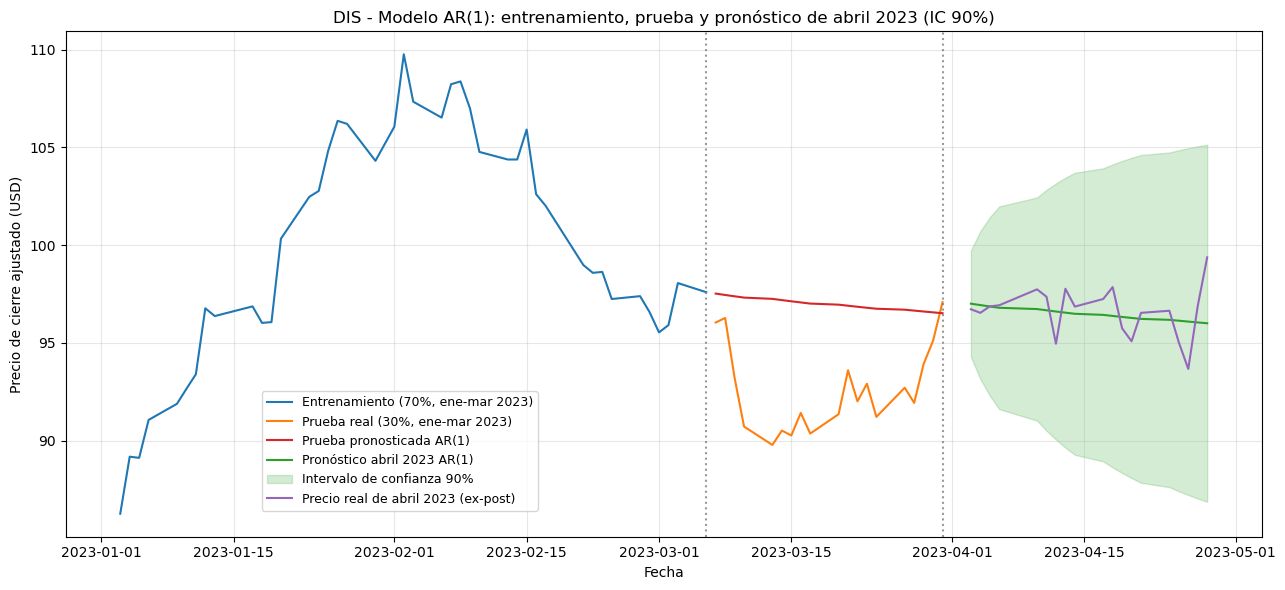

In [55]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(train.index, train.values, color=COLOR_TRAIN, label="Entrenamiento (70%, ene-mar 2023)")
ax.plot(test.index, test.values, color=COLOR_TEST, label="Prueba real (30%, ene-mar 2023)")
ax.plot(pred_test.index, pred_test.values, color=COLOR_TESTHAT, label=f"Prueba pronosticada AR({p_optimo})")

ax.plot(resumen_abril.index, resumen_abril["pronostico"], color=COLOR_FCST, label=f"Pronóstico abril 2023 AR({p_optimo})")
ax.fill_between(resumen_abril.index, resumen_abril["ic90_inferior"], resumen_abril["ic90_superior"],
                color=COLOR_CI, alpha=0.2, label="Intervalo de confianza 90%")

if len(precios_reales_abril) > 0:
    ax.plot(precios_reales_abril.index, precios_reales_abril.values, color=COLOR_REAL_APR, label="Precio real de abril 2023 (ex-post)")

ax.axvline(train.index[-1], color="gray", linestyle=":", alpha=0.8)
ax.axvline(serie_modelo.index[-1], color="gray", linestyle=":", alpha=0.8)

ax.set_title(f"DIS - Modelo AR({p_optimo}): entrenamiento, prueba y pronóstico de abril 2023 (IC 90%)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Precio de cierre ajustado (USD)")
ax.legend(bbox_to_anchor=(0.4, 0.3), fontsize=9)

plt.tight_layout()
plt.show()

## 12. Interpretación de resultados y conclusiones

- Orden del modelo:  
Con base en la PACF y los criterios de información (AIC, BIC), el orden autorregresivo óptimo para la serie de precios de DIS en enero–marzo 2023 fue AR(1).

- Comparación con benchmark ingenuo (Random Walk):  
El AR(1) superó consistentemente al pronóstico ingenuo en el conjunto de prueba (RMSE 4.853 vs. 5.383 USD). La mejora, aunque moderada, confirma que el modelo captura estructura autorregresiva genuina, asociada a la reversión hacia la media. El coeficiente 𝜙 ≈ 0.968, cercano a 1, explica por qué la ventaja frente al paseo aleatorio es limitada.

- Desempeño del modelo:   
El MAPE para el pronóstico de abril (1.00%) mejoró comparado con el MAPE en prueba (4.79%) lo que indica que el modelo pronyectó mejor al mes completo que realmente le pedían pronosticar. El intervalo de confianza del 90% se amplió de 5.44 USD (3 de abril) a 18.27 USD (28 de abril), reflejando el aumento esperado de la incertidumbre con el horizonte de pronóstico, aunque el punto central del pronóstico se mantuvo cerca de los valores reales.

- Comportamiento del pronóstico:  
El modelo proyectó una trayectoria prácticamente plana (de 97.01 a 96.01 USD en abril), coherente con un AR(1) con 𝜙 cercano a 1 y media de largo plazo en 94.74 USD. Los precios reales oscilaron entre 93.67 y 99.38 USD, sin desviarse sostenidamente, en línea con la Hipótesis de Mercados Eficientes. El intervalo de confianza cubrió el 100% de los valores reales, lo que sugiere que fue conservador para un mes relativamente estable.

- Limitaciones y mejoras posibles:  
El AR(1) univariado en niveles no incorpora información exógena (noticias, resultados, condiciones macroeconómicas). Su pronóstico tiende a aplanarse y funciona mejor en periodos estables, pero puede fallar en escenarios volátiles. Para mejorar la precisión se recomienda explorar: ARIMA con diferenciación, GARCH para modelar volatilidad, ARIMAX con variables exógenas que capturen información de mercado más amplia.